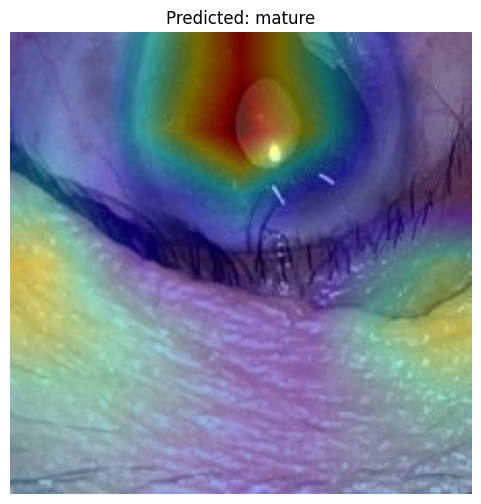

Prediction: mature
Confidence: 0.9996449947357178


In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os

# ====== PATHS ======
MODEL_PATH = r"D:\Project\ML project\smart-eye-diagnosis\models\final_model.h5"
IMG_PATH = r"D:\Project\ML project\smart-eye-diagnosis\data\raw\test\mature\aug_0_631_jpeg.rf.d8a2282c39a8d05649485aaba54fdec0.jpg"

# ====== LOAD MODEL ======
model = keras.models.load_model(MODEL_PATH)

# ====== CLASS NAMES ======
class_names = ['immature', 'mature', 'normal', 'pterygium']

# ====== LOAD IMAGE SAFELY ======
img = cv2.imread(IMG_PATH)

if img is None:
    raise ValueError(f"❌ Image not found at: {IMG_PATH}")

img = cv2.resize(img, (224, 224))

# Save original for overlay
original_img = img.copy()

# ====== PREPROCESS ======
img_array = np.expand_dims(img, axis=0)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

# ====== FIND LAST CONV LAYER ======
last_conv_layer_name = "top_conv"  # EfficientNetB0

# ====== GRAD MODEL ======
grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[model.get_layer(last_conv_layer_name).output, model.output]
)

# ====== GRAD-CAM ======
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    class_id = np.argmax(predictions[0])
    loss = predictions[:, class_id]

grads = tape.gradient(loss, conv_outputs)

# Global Average Pooling
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]

# Weight feature maps
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Normalize
heatmap = np.maximum(heatmap, 0)
if np.max(heatmap) != 0:
    heatmap /= np.max(heatmap)
# ====== HEATMAP PROCESSING ======
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Overlay
superimposed_img = cv2.addWeighted(original_img, 0.6, heatmap, 0.4, 0)

# ====== SHOW RESULTS ======
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {class_names[class_id]}")
plt.axis('off')
plt.show()

# ====== PRINT RESULT ======
confidence = np.max(predictions[0])
print("Prediction:", class_names[class_id])
print("Confidence:", float(confidence))